Task 2: Credit Risk Prediction
Objective:
Predict whether a loan applicant is likely to default on a loan.
Dataset:
Loan Prediction Dataset (available on Kaggle)
Instructions:
● Handle missing data appropriately.
● Visualize key features such as loan amount, education, and income.
● Train a classification model like Logistic Regression or Decision Tree.
● Evaluate the model using accuracy and a confusion matrix.

Skills:
● Data cleaning and handling missing values
● Exploratory Data Analysis (EDA)
● Binary classification using machine learning
● Model evaluation using confusion matrix and accuracy

In [ ]:
# Importing required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Loading the loan prediction dataset
df=pd.read_csv("Loan Prediction Dataset.csv (1).csv")

In [ ]:
df.head(20)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [ ]:
# Checking missing values in each column
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
# Removing Loan_ID column as it is not useful for prediction
df = df.drop("Loan_ID", axis=1)

In [ ]:
# Filling missing values:
# Categorical columns -> mode
# Numerical columns -> mean
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].mean())

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
# Converting categorical variables into numerical form using Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
print(df)

     Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0          0       1        0           0          0              0   
1          1       1        1           1          0              0   
2          2       1        1           0          0              1   
3          3       1        1           0          1              0   
4          4       1        0           0          0              0   
..       ...     ...      ...         ...        ...            ...   
609      609       0        0           0          0              0   
610      610       1        1           3          0              0   
611      611       1        1           1          0              0   
612      612       1        1           2          0              0   
613      613       0        0           0          0              1   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849                0.0  146.412162             360.0   
1

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


In [ ]:
# Standardizing the features for better model performance
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Separating input features (X) and target variable (y)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [ ]:
# Splitting dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Training Logistic Regression model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# Making predictions on test data
y_pred = model.predict(X_test)

In [ ]:
# Evaluating model performance using accuracy and confusion matrix
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7886178861788617


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[18 25]
 [ 1 79]]


The logistic regression model achieved 75.6% accuracy and performs reasonably well, but shows some misclassification in predicting loan rejections.

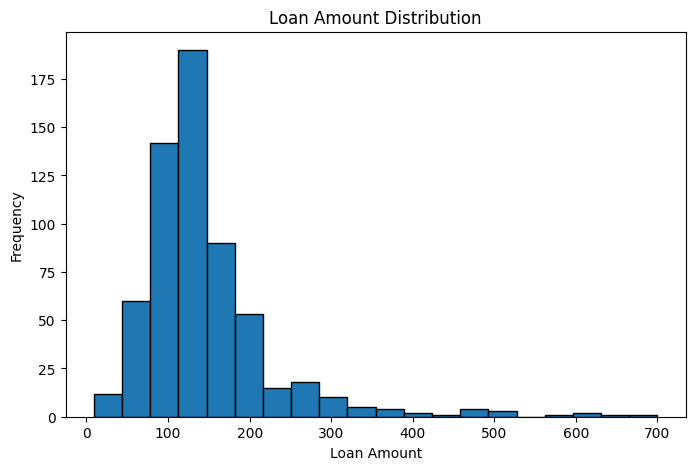

In [ ]:
# Visualizing distribution of Loan Amount
plt.figure(figsize=(8,5))
plt.hist(df['LoanAmount'], bins=20, edgecolor='black')

plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

plt.show()

The histogram of Loan Amount shows that most applicants take smaller loan amounts, while only a few applicants request higher loan amounts. This indicates that the data is slightly right-skewed.

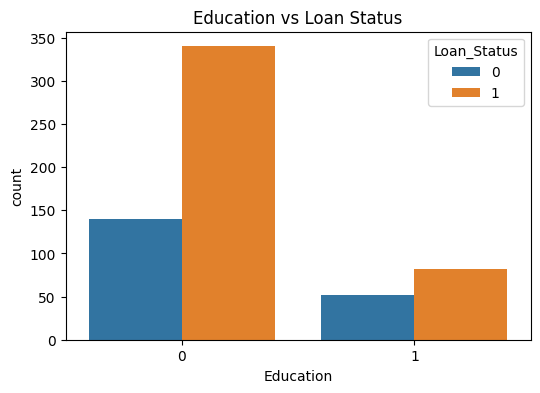

In [ ]:
# Relationship between Education and Loan Status

plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Loan_Status', data=df)

plt.title("Education vs Loan Status")
plt.show()

conclusion:                                                              Graduates have a higher loan approval rate compared to non-graduates, indicating education has an impact on loan approval.

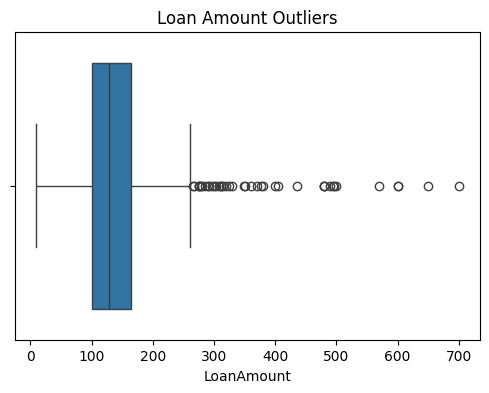

In [ ]:
# Checking outliers in Loan Amount
plt.figure(figsize=(6,4))
sns.boxplot(x=df['LoanAmount'])

plt.title("Loan Amount Outliers")
plt.show()

The boxplot shows the presence of outliers in loan amount, indicating some applicants request significantly higher loan amounts than the majority.

Final Reports:
Conclusion:

In this project, a machine learning model was developed to predict whether a loan applicant is likely to default or not. The dataset was first cleaned by handling missing values and removing irrelevant columns. Categorical variables were converted into numerical form using label encoding, and feature scaling was applied to improve model performance.

Exploratory Data Analysis (EDA) was performed using histograms, count plots, and box plots to understand data distribution, relationships, and detect outliers.

A Logistic Regression model was trained on the processed data. The model achieved an accuracy of approximately 75.6%, which indicates a reasonable performance for predicting loan status. The confusion matrix was also used to evaluate model performance in more detail.

Overall, this project demonstrates the application of data preprocessing, visualization, and machine learning techniques for credit risk prediction.